## 🧑‍🏫 Step1-> Importing all the libraries and modules

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

## 🧑‍🏫 Step2-> Importing data from CSV file

In [50]:
df = pd.read_csv("housing.csv")

## 🧑‍🏫 Step3 -> Checking the distribution of price in out data 

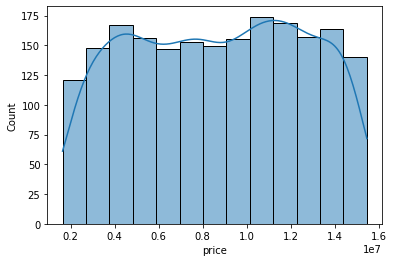

In [6]:
sns.histplot(df['price'], kde = True)
plt.show()

## 🧑‍🏫 Step4 -> Relationship between area and price

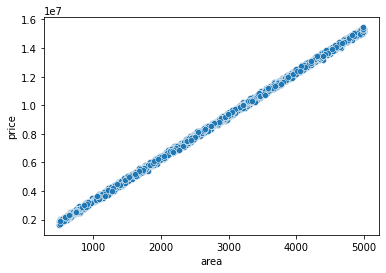

In [7]:
sns.scatterplot(x ='area', y = 'price', data = df)
plt.show()

## 🧑‍🏫 Step 5 -> Checking the correlation between all the features and target in our data

In [8]:
corr = df.corr()
corr

,area,bedrooms,bathrooms,stories,parking,price
area,1.000000,0.047523,0.021881,0.017749,-0.004031,0.999670
bedrooms,0.047523,1.000000,-0.011990,0.010435,0.006542,0.065752
bathrooms,0.021881,-0.011990,1.000000,0.029089,0.014528,0.030626
stories,0.017749,0.010435,0.029089,1.000000,-0.024558,0.026400
parking,-0.004031,0.006542,0.014528,-0.024558,1.000000,-0.000090
price,0.999670,0.065752,0.030626,0.026400,-0.000090,1.000000


## 🧑‍🏫 Step 6 -> Using Heatmap for the visual representation of the correlation

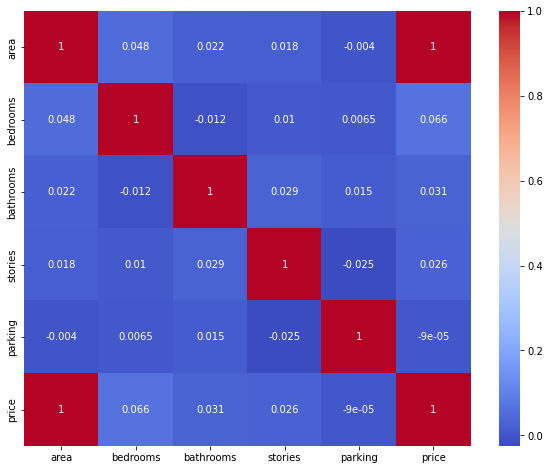

In [9]:
plt.figure(figsize = (10,8))
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.show()

## 🧑‍🏫 Step 7 -> Spliting features and target

In [51]:
x = df.drop('price', axis = 1)
y = df["price"]

## 🧑‍🏫 Step 8 -> Train test split

In [52]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

## 🧑‍🏫 Step 9 -> Model creation and model training

In [13]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

## 🧑‍🏫 Step 10 -> Prediction

In [14]:
y_pred = model.predict(x_test)
print(y_pred[0])

2193339.5439382866


## 🧑‍🏫 Step 11 -> Model evaluation(How wrong model is) using -> MAE, MSE and RMSE

### MAE

In [15]:
mae = mean_absolute_error(y_test, y_pred)
mae

39935.740557726494

### MSE

In [16]:
mse = mean_squared_error(y_test,y_pred)
mse

2634569539.2888274

In [17]:
rmse = np.sqrt(mse)
rmse

51328.058012054455

## 🧑‍🏫 Step 12 -> Feature Importance

In [40]:
coefficients = model.coef_
coeff = pd.DataFrame({
    "Features": x.columns,
    "Coefficients": coefficients
})
coeff.sort_values(by = 'Coefficients', ascending = False)

,Features,Coefficients
1,bedrooms,49313.601376
3,stories,40427.706929
2,bathrooms,30412.475064
4,parking,19311.030502
0,area,2998.855929


In [42]:
print(model.intercept_)

4622.764361292124


## 🧑‍🏫 Step 13 -> VISUALIZING PREDICTIONS

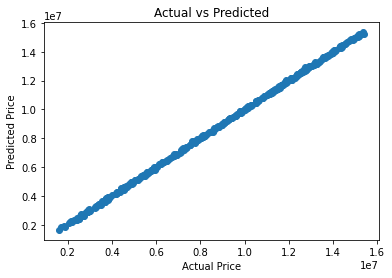

In [55]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

### “The model shows strong predictive performance as the predicted values closely align with actual values.”